## Notebook: Embedding Generation with TerraTorch

In this notebook, we generate and explore EO embeddings for the HLS Burn Scars dataset. TerraTorch makes it easy to generate embeddings using pretrained EO foundation models on your own data.

We start with the imports we need:

In [1]:
import numpy as np
import lightning.pytorch as pl
from pathlib import Path
import rasterio
import matplotlib.pyplot as plt
import albumentations
from ipywidgets import interact, IntSlider
from terratorch.datasets.utils import to_pca_rgb

import warnings
warnings.filterwarnings('ignore')

### 1. Importing the relevant TerraTorch components

TerraTorch is built on PyTorch and Lightning and organizes workflows into a few reusable components:

- A **trainer** that runs the workflow
- A **task** that defines the model and workflow behavior
- A **datamodule** that loads and preprocesses the data

![TerraTorch Overview](terratorch_overview.png)

For this tutorial:
- We use `GenericNonGeoSegmentationDataModule` to load the HLS data
- We use `EmbeddingGenerationTask` to generate and save EO embeddings

In [6]:
from terratorch.datamodules import GenericNonGeoSegmentationDataModule
from terratorch.tasks import EmbeddingGenerationTask

### 2. Downloading the input image data (to be updated)

In [7]:
import gdown

# This version is an adaptation from https://huggingface.co/datasets/ibm-nasa-geospatial/hls_burn_scars (same data, updated folder structure) with splits from https://github.com/IBM/peft-geofm/tree/main/datasets_splits/burn_scars. You can also download the original data from Hugging Face.

dataset_path = Path('hls_burn_scars') # Path to the extracted dataset (change this if your data lives elsewhere)
archive_path = dataset_path.with_suffix(".tar.gz")

# Download archive if it does not exist
if not archive_path.is_file():
    gdown.download("https://drive.google.com/uc?id=1yFDNlGqGPxkc9lh9l1O70TuejXAQYYtC")

# Extract archive if dataset directory does not exist
if not dataset_path.is_dir():
    !tar -xzf {archive_path}

### 3. Building the Datamodule

This step defines how TerraTorch loads the images we want to embed:
- where the images are stored
- which files should be loaded
- how the images should be normalized

Normalization values should match the foundation model pretraining setup and your data.  
Here we use the Sentinel-2 L2A normalization statistics used by TerraMind during pretraining, asssuming a data range of `[0,1]` which matches our dataset. We only need the values for the 6 HLS bands available in this dataset:

```python
means = [0.1503, 0.1718, 0.1853, 0.3132, 0.2424, 0.1857]
stds  = [0.2141, 0.2038, 0.2134, 0.1753, 0.1434, 0.1334]
```

In [8]:
datamodule = GenericNonGeoSegmentationDataModule(
    batch_size=1,
    num_workers=2,
    num_classes=2,  # Required by the datamodule; not used for embedding generation
    check_stackability=False, # We can skip stackability check for datasets with a known, consistent input size

    predict_data_root=dataset_path / "data/",
    img_grep="*_merged.tif",  
    label_grep='*.mask.tif',
    
    # Matching TerraMind pretraining values
    means=[0.1503, 0.1718, 0.1853, 0.3132, 0.2424, 0.1857],
    stds=[0.2141, 0.2038, 0.2134, 0.1753, 0.1434, 0.1334],

    predict_transform=[
        albumentations.RandomCrop(224, 224),
    ],

    no_data_replace=0,  # Replace no-data / NaNs
    return_georeference=True
)

Before generating embeddings, we inspect a few input samples loaded by the datamodule to verify that the data is loaded correctly.

Available input samples: 804


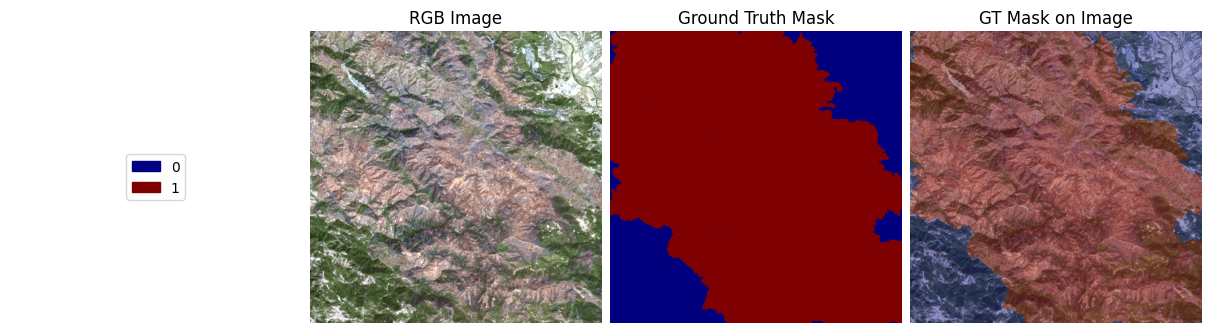

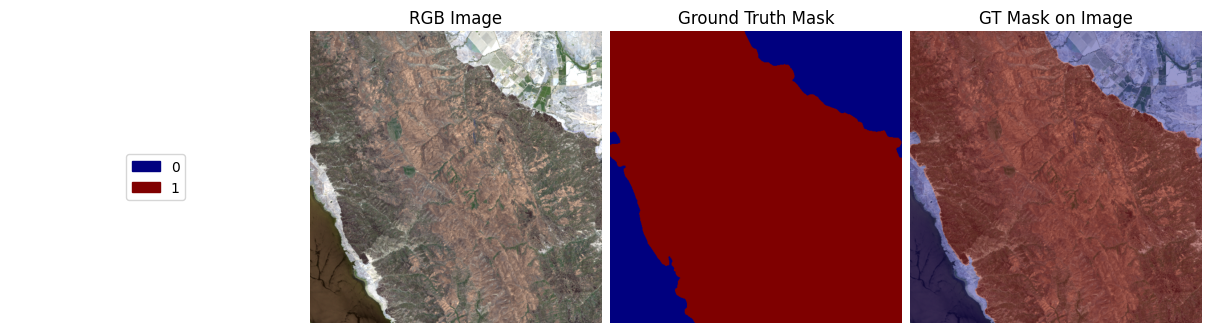

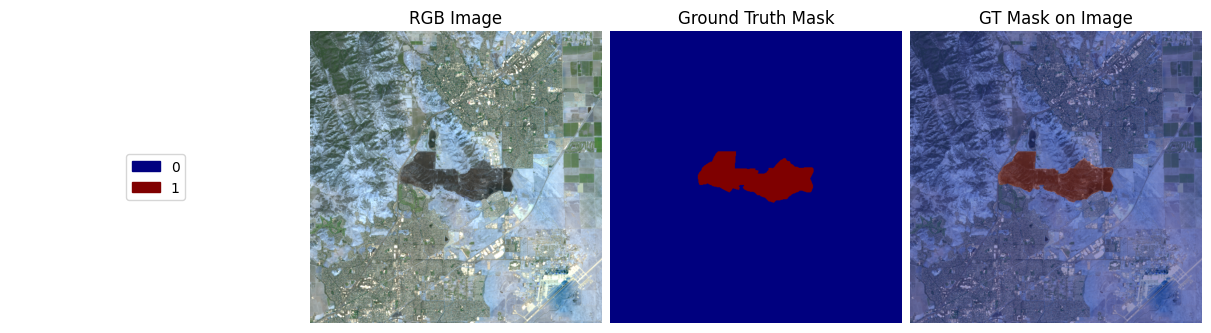

In [9]:
# Set up the datamodule for prediction
datamodule.setup("predict")

# Check the datamodule initialization and dataset length
dataset = datamodule.predict_dataset
print(f"Available input samples: {len(dataset)}")

for i in range(0,3):
    _ = dataset.plot(dataset[i])

### 4. Building the Embedding Generation Task

Next, we configure the embedding generation task.

Instead of fine-tuning the full foundation model for every downstream task, we generate reusable embeddings that can later be used by smaller downstream models.

<div style="text-align: center;">
  <img src="FM_vs_embedding.png" width="850">
</div>

In [ ]:
model = EmbeddingGenerationTask(

    # Select and configure the backbone model as in other TerraTorch workflows
    model_args={
        "backbone": "terramind_v1_small",
        "backbone_modalities": ["S2L2A"],
        "backbone_pretrained": True,
        "backbone_bands": {"S2L2A": ["BLUE", "GREEN", "RED", "NIR_NARROW", "SWIR_1", "SWIR_2"]},
    },

    # Embedding workflow–specific configuration
    output_format="tiff",  # Save embeddings as GeoTIFFs
    output_dir=dataset_path / "embeddings_terramind/",
    layers=[-1],  # Layers to extract embeddings from; "-1" indicates the final layer
    embedding_pooling=None,  # Keep dense embeddings (recommended for pixel-wise downstream tasks)
)

Additionally, TerraTorch supports different layer selection and embedding pooling strategies for more flexible experimentation.

Different layers often capture different types of information, while pooling controls whether embeddings keep spatial structure or are aggregated into a single vector representation.

<div style="text-align: center;">
  <img src="design_choices.png" width="650">
</div>

We can now run the embedding generation workflow and save the resulting embeddings to disk.

In [ ]:
# Generate embeddings
trainer = pl.Trainer(accelerator="auto")
_ = trainer.predict(model, datamodule=datamodule)

### 5. Trying a Different Backbone

Using the same workflow, we now generate embeddings with a different backbone: Prithvi v2 300. We then compare the resulting embeddings using PCA visualizations.

In [12]:
# As we change the backbone, we update the normalization applied in the datamodule to the Prithvi pretraining values.
from terratorch.datamodules.generic_pixel_wise_data_module import Normalize

means = [0.1087, 0.1342, 0.1433, 0.2734, 0.1958, 0.1363]
stds = [0.2248, 0.2179, 0.2178, 0.1850, 0.1242, 0.1049]

datamodule.aug = Normalize(means, stds)
datamodule.setup("predict")

**TASK**: Now it is your turn to set up the Prithvi embedding task. The template below is kept as a markdown cell. To complete the exercise, convert the next cell to a Python code cell and fill in the fields:

- To use the Prithvi v2 model in its 300M parameter configuration, use the model name `prithvi_eo_v2_300`
- For easier comparison later, use TIFF output format again
- Different from TerraMind, Prithvi uses a CLS token, we need to pass this info to the task

model = EmbeddingGenerationTask(

    model_args={
        "backbone": "<fill>",
        "backbone_pretrained": <fill>,
        "backbone_img_size": <fill>, # Fill in the pixel size of our input images as int
        "backbone_bands": <fill>,
    },

    output_format="<fill>",
    output_dir=dataset_path / "embeddings_prithvi/",
    layers=[<fill>],
    embedding_pooling=<fill>,
    has_cls=<fill>,
)


In [ ]:
# Generate embeddings
trainer = pl.Trainer(accelerator="auto")
_ = trainer.predict(model, datamodule=datamodule)

### 6. Inspecting results

We define two plotting helper functions: one for the raw RGB image, and one for a PCA-RGB view of the embeddings.

In [14]:
def load_raw_rgb(path: Path) -> np.ndarray:
    """Load raw image and process to RGB"""
    with rasterio.open(path) as src:
        raw = src.read()  # (C, H, W)

    data = raw.astype(np.float32)
    if data.mean() < 1:
        data *= 10000.0

    data = (data.clip(0, 2000) / 2000) * 255.0
    rgb = data[[2, 1, 0]].astype(np.uint8).transpose(1, 2, 0)  # (H, W, 3)
    return rgb

def load_emb_pca_rgb(path: Path, *, step: int = 8) -> np.ndarray:
    """Load embedding GeoTIFF and map to PCA-RGB."""
    with rasterio.open(path) as src:
        emb = src.read().astype(np.float32)  # (C, H, W)

    emb_rgb, _, _ = to_pca_rgb(image_chw=emb, step=step)  # predefined in your notebook
    return emb_rgb

Below, we compare PCA projections of our generated embeddings. If you succesfully ran the Prithvi embedding generation you should see both Prithvi and TerraMind embeddings, otherwise you will only see TerraMind embeddings plotted.

The PCA projection is computed separately for each image and helps visualize spatial patterns in the embeddings.

In [17]:
N_SAMPLES = 40

DATA_DIR = dataset_path / "data"
EMB_TM = dataset_path / "embeddings_terramind/layer_00"
EMB_PR = dataset_path / "embeddings_prithvi/layer_00"

def files(folder, suffix):
    if not folder.is_dir():
        return {}
    return {p.stem.removesuffix(suffix): p for p in folder.glob(f"*{suffix}.tif")}

raw = files(DATA_DIR, "_merged")
tm = files(EMB_TM, "_merged_embedding")
pr = files(EMB_PR, "_merged_embedding")

# Require raw images and TerraMind embeddings.
# Add Prithvi embeddings only where available.
names = sorted(set(raw) & set(tm))[:N_SAMPLES]

def show_sample(i=0):
    name = names[i]

    imgs = [
        load_raw_rgb(raw[name]),
        load_emb_pca_rgb(tm[name], step=8),
    ]
    titles = ["Raw RGB", "TerraMind PCA RGB"]

    if name in pr:
        try:
            imgs.append(load_emb_pca_rgb(pr[name], step=8))
            titles.append("Prithvi PCA RGB")
        except Exception as e:
            print(f"Could not load Prithvi embedding for {name}: {e}")

    fig, axs = plt.subplots(1, len(imgs), figsize=(4 * len(imgs), 4))

    if len(imgs) == 1:
        axs = [axs]

    for ax, img, title in zip(axs, imgs, titles):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")

    fig.suptitle(name)
    plt.tight_layout()
    plt.show()

interact(
    show_sample,
    i=IntSlider(min=0, max=len(names)-1, step=1, value=0, description="Sample")
)

interactive(children=(IntSlider(value=0, description='Sample', max=39), Output()), _dom_classes=('widget-inter…

<function __main__.show_sample(i=0)>

### Optional task on your own: Generate pooled Parquet embeddings

So far, we saved dense TIFF embeddings that preserve spatial structure.
As an optional extension, try generating one pooled embedding vector per image instead.

Tips:

- switch the output format to `parquet_joint`
- use `embedding_pooling="mean"` to aggregate each image into one embedding vector
- read the resulting Parquet file in to inspect the results, e.g. print the embedding shape or a histogram over the embedding value distribution.

This is useful when you want compact image-level embeddings for downstream tasks like classification, clustering, or similarity search.